# Visualizations for OOD Experiment
This notebook provides a structured visualization of the results from the OOD detection time-series experiments.
Each cell contains all the necessary code to run independently.

## Results Validation and Sanity Check
In order to show if the extraction worked, we list each subset and how many embeddings are correctly extracted.

In [1]:
import pandas as pd
import os

def run_prefixed_audit_with_counts():
    file_path = "../outputs/final_ood_scores.csv"
    
    # expected list
    expected_id = (
        [f"c_{s}" for s in [
            "wiki_daily_100k", "monash_pedestrian_counts", "wind_farms_hourly", "monash_rideshare", 
            "mexico_city_bikes", "solar", "solar_1h", "taxi_1h", "ushcn_daily", "weatherbench_hourly", 
            "weatherbench_daily", "weatherbench_weekly", "wind_farms_daily", "electricity_15min", 
            "monash_electricity_hourly", "monash_electricity_weekly", "monash_kdd_cup_2018", 
            "monash_london_smart_meters", "m4_daily", "m4_hourly", "m4_monthly", "m4_weekly", 
            "taxi_30min", "monash_temperature_rain", "uber_tlc_hourly", "uber_tlc_daily",
            "brazilian_cities_temperature", "spanish_energy_and_weather"
        ]] + 
        [f"g_{s}" for s in [
            "smart", "ideal", "residential_load_power", "residential_pv_power",
            "azure_vm_traces_2017", "borg_cluster_data_2011", "bdg-2_panther", "bdg-2_fox",
            "bdg-2_rat", "bdg-2_bear", "lcl", "sceaux", "borealis", "buildings_900k",
            "largest_2017", "largest_2018", "largest_2019", "largest_2020",
            "largest_2021", "PEMS03", "PEMS04", "PEMS07", "PEMS08", "PEMS_BAY", "LOS_LOOP",
            "BEIJING_SUBWAY_30MIN", "SHMETRO", "HZMETRO", "Q-TRAFFIC", "subseasonal",
            "subseasonal_precip", "wind_power", "solar_power", "kaggle_web_traffic_weekly",
            "kdd2022", "godaddy", "favorita_sales", "china_air_quality", "beijing_air_quality",
            "cdc_fluview_ilinet", "cdc_fluview_who_nrevss"
        ]]
    )

    expected_ood = (
        [f"c_{s}" for s in [
            "monash_australian_electricity", "ercot", "exchange_rate", "monash_traffic", 
            "nn5", "monash_nn5_weekly", "monash_weather", "monash_covid_deaths", "monash_fred_md", 
            "m4_quarterly", "m4_yearly", "dominick", "m5", "monash_tourism_monthly", 
            "monash_tourism_quarterly", "monash_tourism_yearly", "monash_car_parts", "monash_hospital", 
            "monash_cif_2016", "monash_m1_yearly", "monash_m1_quarterly", "monash_m1_monthly", 
            "monash_m3_monthly", "monash_m3_yearly", "monash_m3_quarterly", "ETTm", "ETTh"
        ]] + 
        [f"g_{s}" for s in [
            "jena_weather", "ett1", "bitbrains_fast_storage", "bitbrains_rnd", "bizitobs_application",
            "bizitobs_l2c", "bizitobs_service", "car_parts_with_missing", "covid_deaths", "electricity/D",
            "ett2", "hierarchical_sales", "hospital", "LOOP_SEATTLE", "m4_quarterly",
            "m4_yearly", "M_DENSE", "restaurant", "saugeenday", "solar", "SZ_TAXI", "us_births"
        ]]
    )

    if not os.path.exists(file_path):
        print(f"Error: {file_path} not found.")
        return

    # load and isolate one mode to avoid overcounting
    df_full = pd.read_csv(file_path)
    sample_mode = df_full['norm_mode'].unique()[0]
    df = df_full[df_full['norm_mode'] == sample_mode].copy()

    # analyze group statistics
    print("="*85)
    print(f"{'GROUP':<20} | {'EXPECTED':<10} | {'FOUND':<10} | {'SAMPLES':<10} | {'STATUS'}")
    print("-" * 85)

    for group_name in sorted(df['group'].unique()):
        found_subsets = set(df[df['group'] == group_name]['subset'].unique())
        group_samples = len(df[df['group'] == group_name])
        
        target_list = set(expected_id) if "ID" in group_name else set(expected_ood)
        missing = target_list - found_subsets
        status = "OK" if len(missing) == 0 else f"{len(missing)} MISSING"
        
        print(f"{group_name:<20} | {len(target_list):<10} | {len(found_subsets):<10} | {group_samples:<10} | {status}")
        if missing and group_name != "ID_VAL":
             print(f"   Missing: {sorted(list(missing))[:5]}...")

    # detailed list with per-subset counts
    print("\n" + "="*85)
    print(f"{'GROUP':<20} | {'#':<4} | {'SUBSET NAME':<40} | {'EMBEDDINGS'}")
    print("-" * 85)

    for group_name in sorted(df['group'].unique()):
        group_df = df[df['group'] == group_name]
        subset_counts = group_df.groupby('subset').size().sort_index()
        
        for i, (name, count) in enumerate(subset_counts.items(), 1):
            display_group = group_name if i == 1 else ""
            print(f"{display_group:<20} | {i:<4} | {name:<40} | {count:<10}")
        print("-" * 85)


if __name__ == "__main__":
    run_prefixed_audit_with_counts()

GROUP                | EXPECTED   | FOUND      | SAMPLES    | STATUS
-------------------------------------------------------------------------------------
ID_TRAIN             | 69         | 69         | 58123      | OK
ID_VAL               | 69         | 69         | 11840      | OK
OOD_BENCHMARK        | 49         | 49         | 33801      | OK

GROUP                | #    | SUBSET NAME                              | EMBEDDINGS
-------------------------------------------------------------------------------------
ID_TRAIN             | 1    | c_brazilian_cities_temperature           | 9         
                     | 2    | c_electricity_15min                      | 1000      
                     | 3    | c_m4_daily                               | 1000      
                     | 4    | c_m4_hourly                              | 331       
                     | 5    | c_m4_monthly                             | 1000      
                     | 6    | c_m4_weekly                  

We assess the effectiveness of the Mahalanobis baseline by comparing the OOD scores generated for ID training, ID validation and OOD samples. This cross-group comparison reveals whether the baseline produces a consistent and meaningful separation between ID and OOD data.

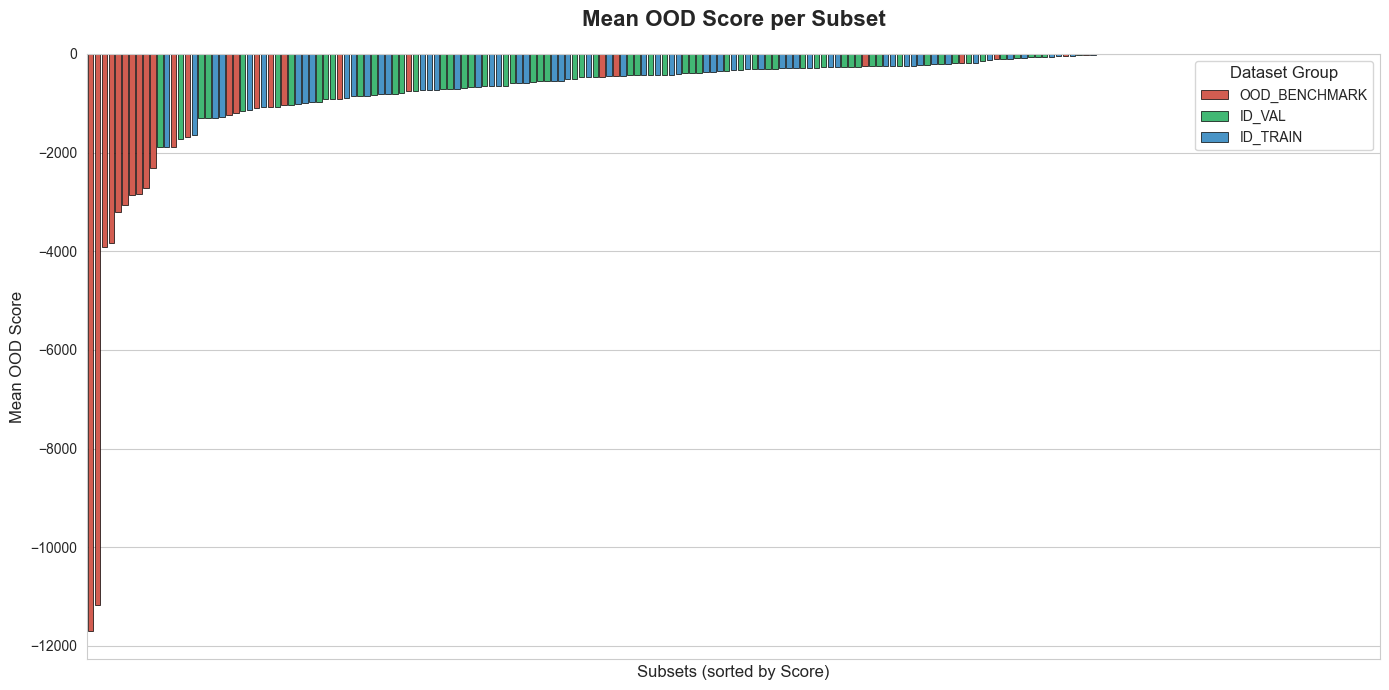

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

def plot_ood_bar_chart():
    # loading data
    file_path = "../outputs/final_ood_scores.csv"
    if not os.path.exists(file_path):
        print(f"Error: file {file_path} not found.")
        return
        
    df = pd.read_csv(file_path)
    
    # fix reference mode
    reference_mode = "l2_ln"
    df_filtered = df[df['norm_mode'] == reference_mode]
    
    grouped = df_filtered.groupby(['group', 'subset'])['ood_score'].mean().reset_index()
    
    # sort by score
    grouped = grouped.sort_values(by='ood_score').reset_index(drop=True)
    
    # define colors for ID train/val and OOD sets
    palette = {
        'ID_TRAIN': '#3498db', 
        'ID_VAL': '#2ecc71', 
        'OOD_BENCHMARK': '#e74c3c'
    }

    plt.figure(figsize=(14, 7))
    sns.set_style("whitegrid")
    
    ax = sns.barplot(
        data=grouped,
        x=grouped.index, 
        y='ood_score',
        hue='group',
        palette=palette,
        dodge=False,
        edgecolor='black',
        linewidth=0.5
    )
    
    plt.title(f"Mean OOD Score per Subset", fontsize=16, fontweight='bold', pad=20)
    plt.ylabel("Mean OOD Score", fontsize=12)
    plt.xlabel("Subsets (sorted by Score)", fontsize=12)
    
    ax.set_xticks([])
    
    plt.legend(title="Dataset Group", title_fontsize='12', fontsize='10', loc='upper right')
    output_path = "../outputs/ood_separation.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.tight_layout()    
    plt.show()

if __name__ == "__main__":
    plot_ood_bar_chart()

Here is even a more detailed overview of OOD scores for ID and OOD datasets.

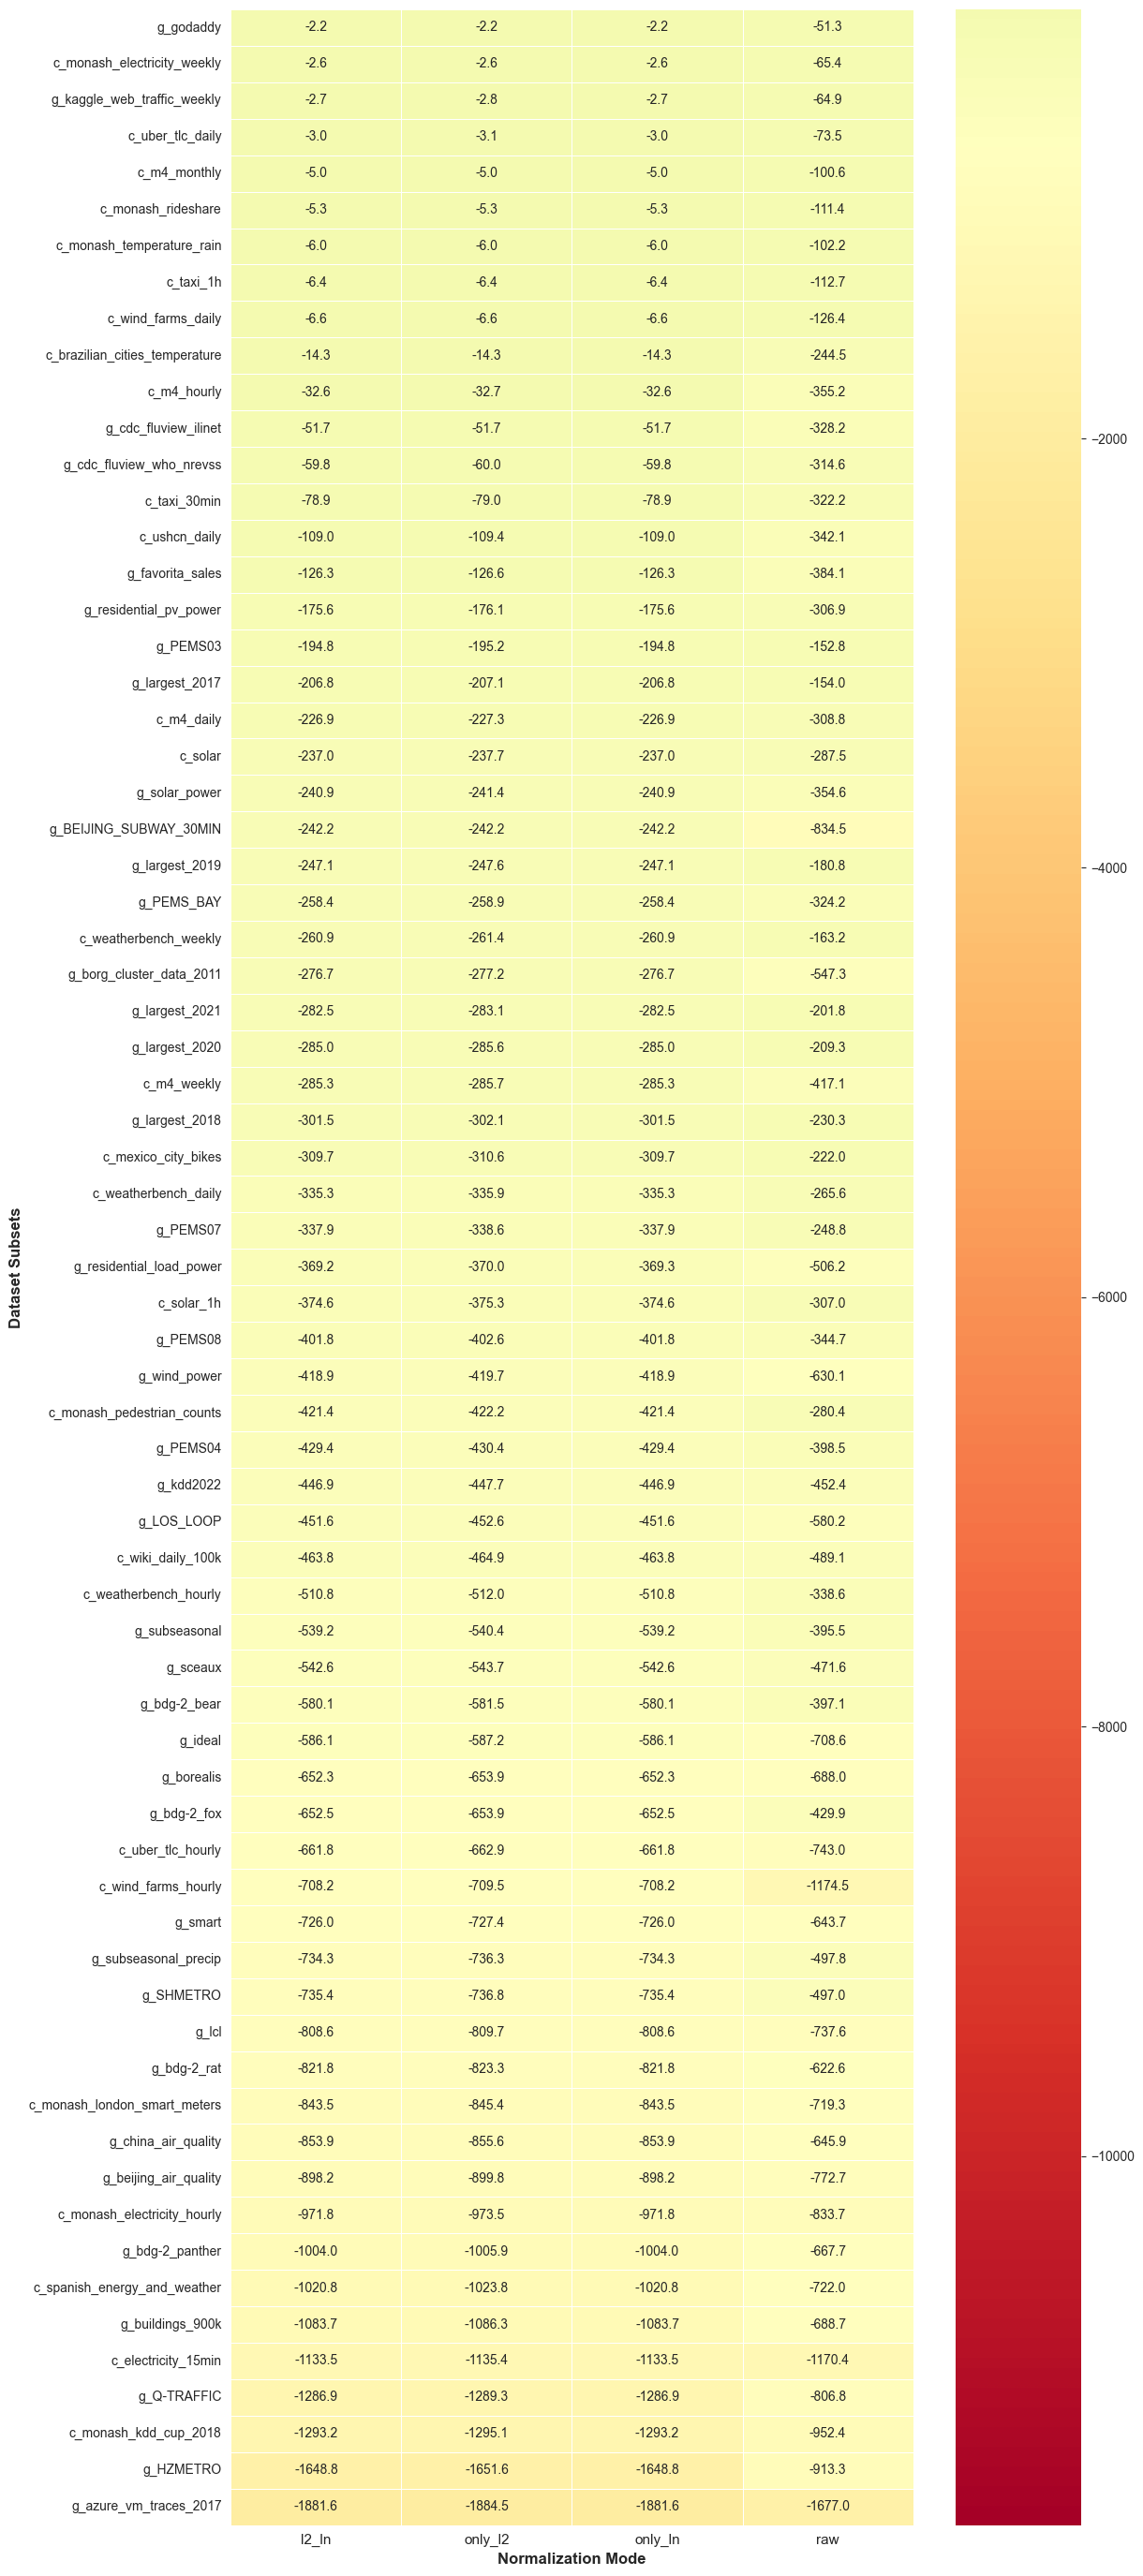

Saved: ../outputs/ood_analysis_id_train.png


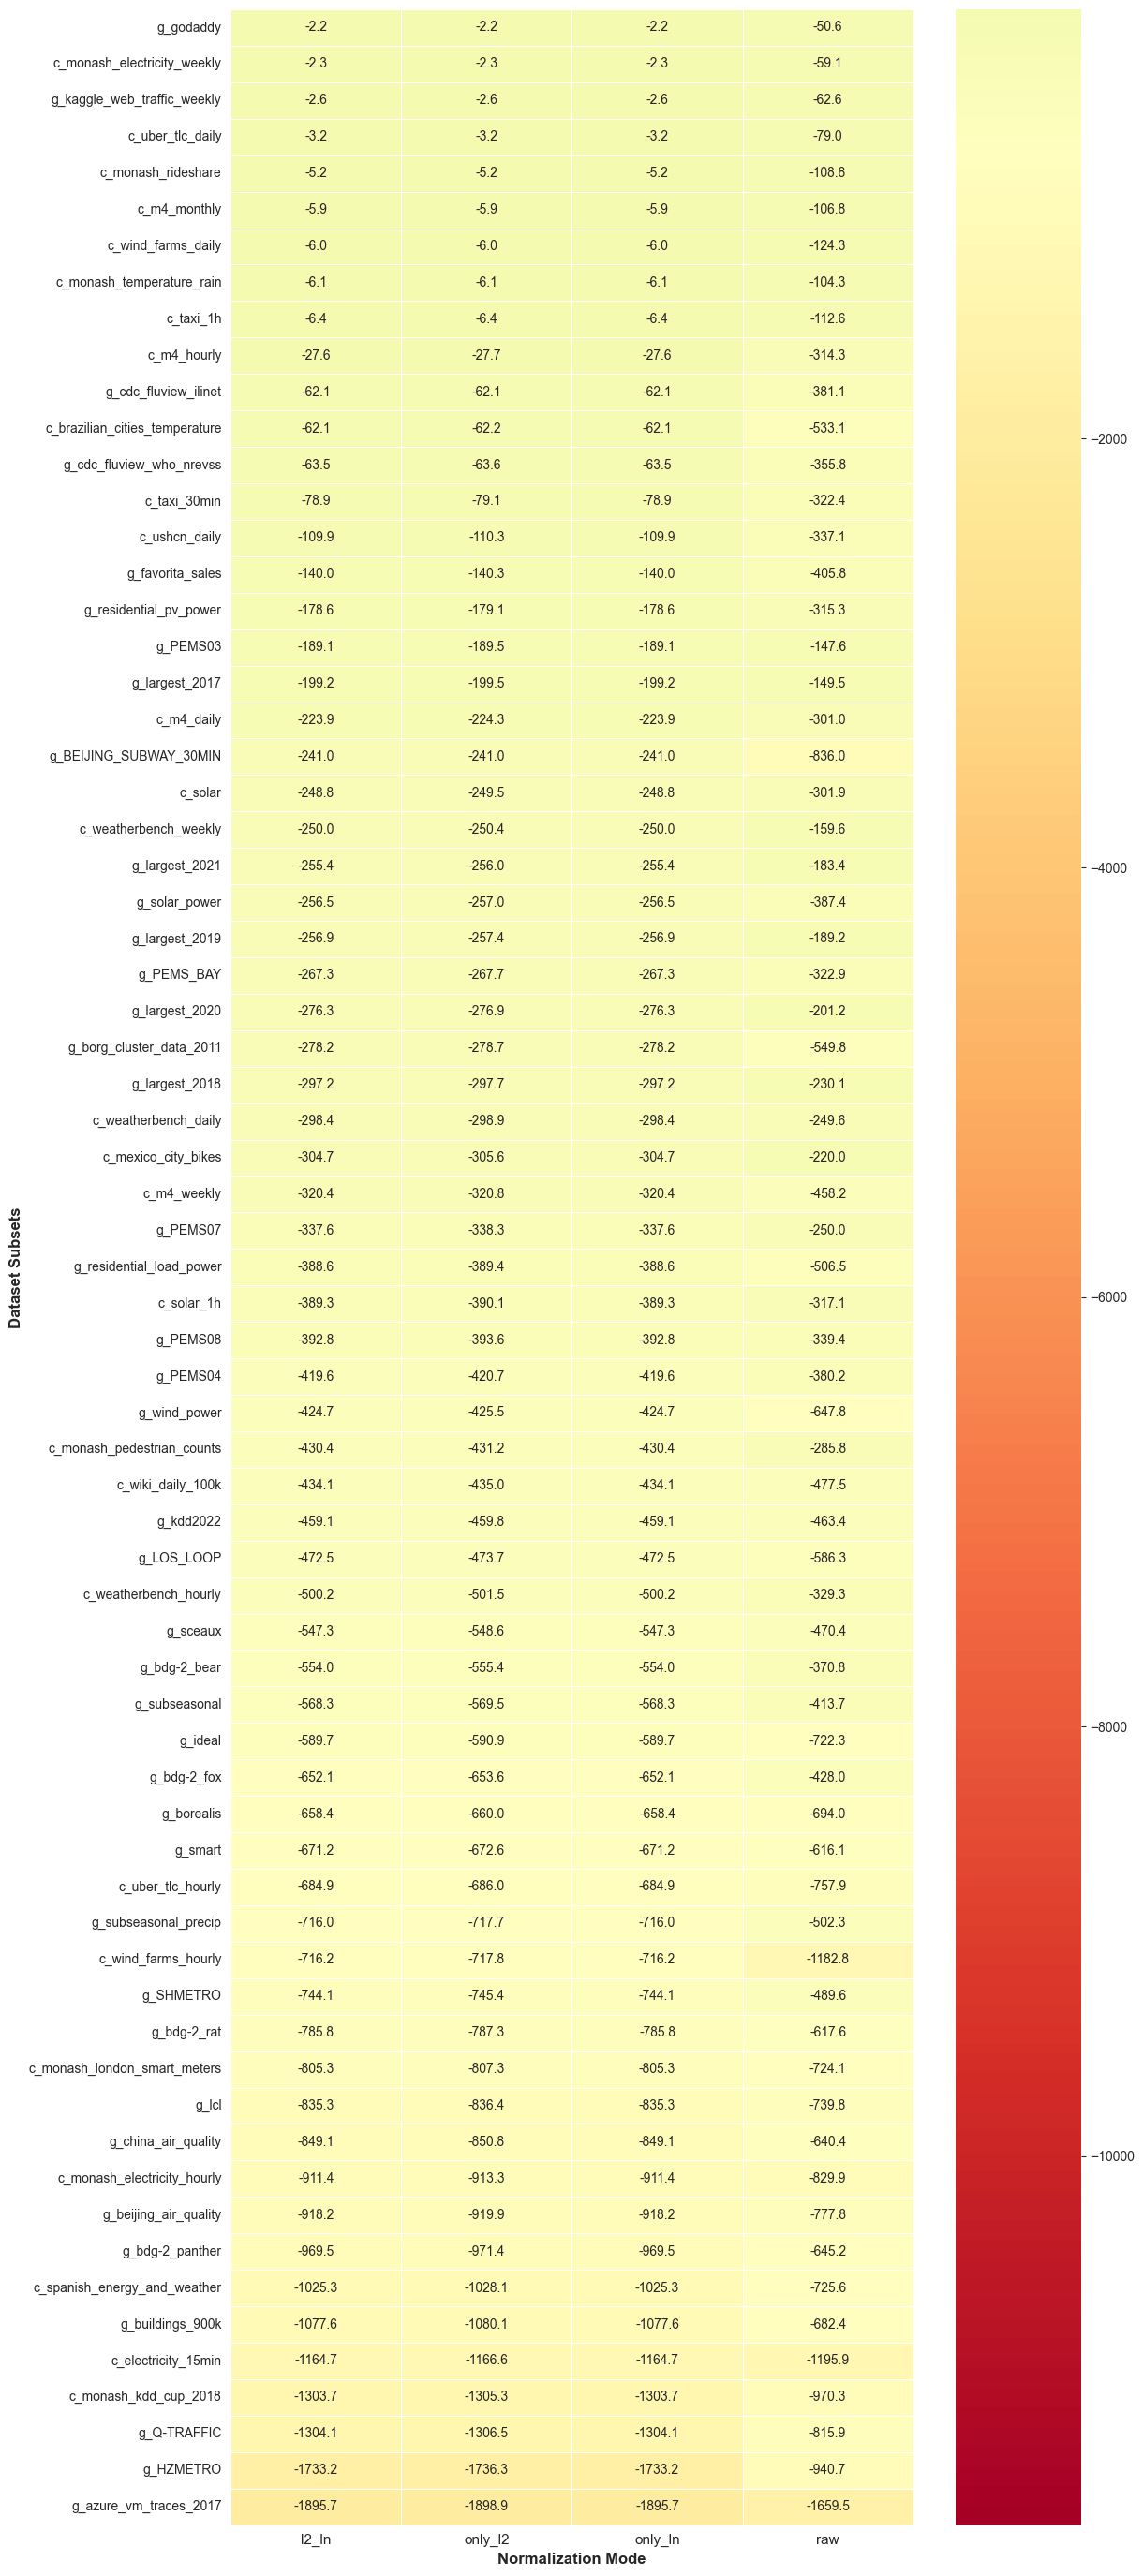

Saved: ../outputs/ood_analysis_id_val.png


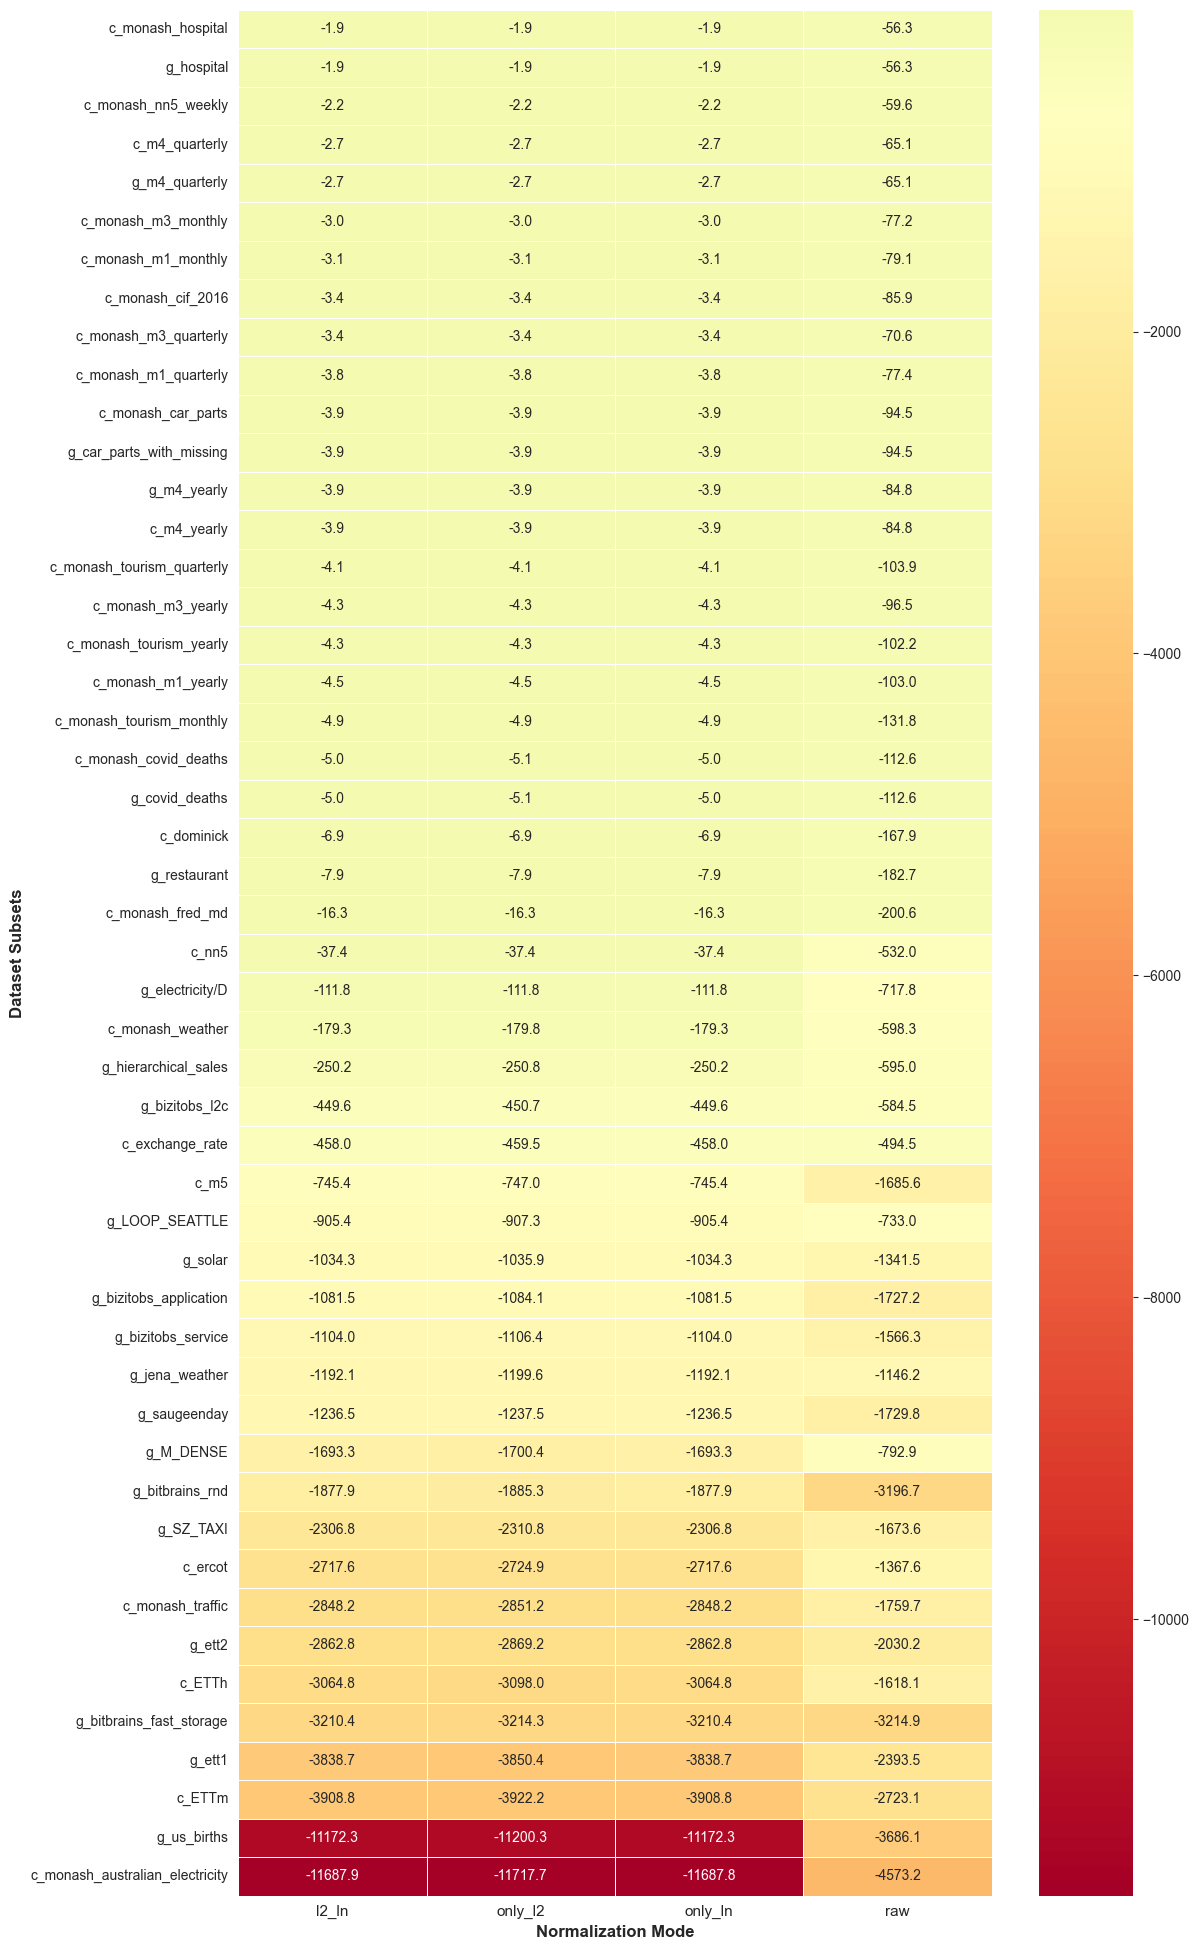

Saved: ../outputs/ood_analysis_ood_benchmark.png


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

def plot_individual_heatmaps():
    file_path = "../outputs/final_ood_scores.csv"
    if not os.path.exists(file_path):
        print(f"Error: {file_path} not found.")
        return
        
    df = pd.read_csv(file_path)
    
    # aggregate data
    grouped = df.groupby(['group', 'subset', 'norm_mode'])['ood_score'].mean().reset_index()
    pivot_df = grouped.pivot_table(index=['group', 'subset'], 
                                   columns='norm_mode', 
                                   values='ood_score')
    
    # calculate global stats to keep coloring consistent
    global_vmin = pivot_df.values.min()
    global_vmax = pivot_df.values.max()
    global_center = pivot_df.values.mean()
    
    group_order = ['ID_TRAIN', 'ID_VAL', 'OOD_BENCHMARK']
    existing_groups = [g for g in group_order if g in pivot_df.index.get_level_values(0)]
    
    for g in existing_groups:
        # extract and sort
        group_df = pivot_df.xs(g, level=0)
        group_df = group_df.sort_values(by='l2_ln', ascending=False)
        
        # adjust height dynamically based on the number of subsets in this group
        num_subsets = len(group_df)
        dynamic_height = max(8, num_subsets * 0.4)
        
        plt.figure(figsize=(12, dynamic_height))
        
        # generate the heatmap
        ax = sns.heatmap(group_df, 
                         cmap="RdYlGn", 
                         vmin=global_vmin, 
                         vmax=global_vmax,
                         center=global_center,
                         annot=True, 
                         fmt=".1f", 
                         linewidths=.5,
                        )
        
        plt.xlabel("Normalization Mode", fontsize=12, fontweight='bold')
        plt.ylabel("Dataset Subsets", fontsize=12, fontweight='bold')
        plt.yticks(rotation=0, fontsize=10)
        plt.xticks(fontsize=11)
        
        # save
        output_filename = f"../outputs/ood_analysis_{g.lower()}.png"
        plt.tight_layout()
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Saved: {output_filename}")

if __name__ == "__main__":
    plot_individual_heatmaps()

## Performance Analysis
To quantify the impact of feature transformations on OOD detection, we calculate the AUROC and FPR@95%TPR across all experimental configurations.

Generated: ../outputs/metrics_raw.png
Generated: ../outputs/metrics_only_l2.png
Generated: ../outputs/metrics_only_ln.png
Generated: ../outputs/metrics_l2_ln.png


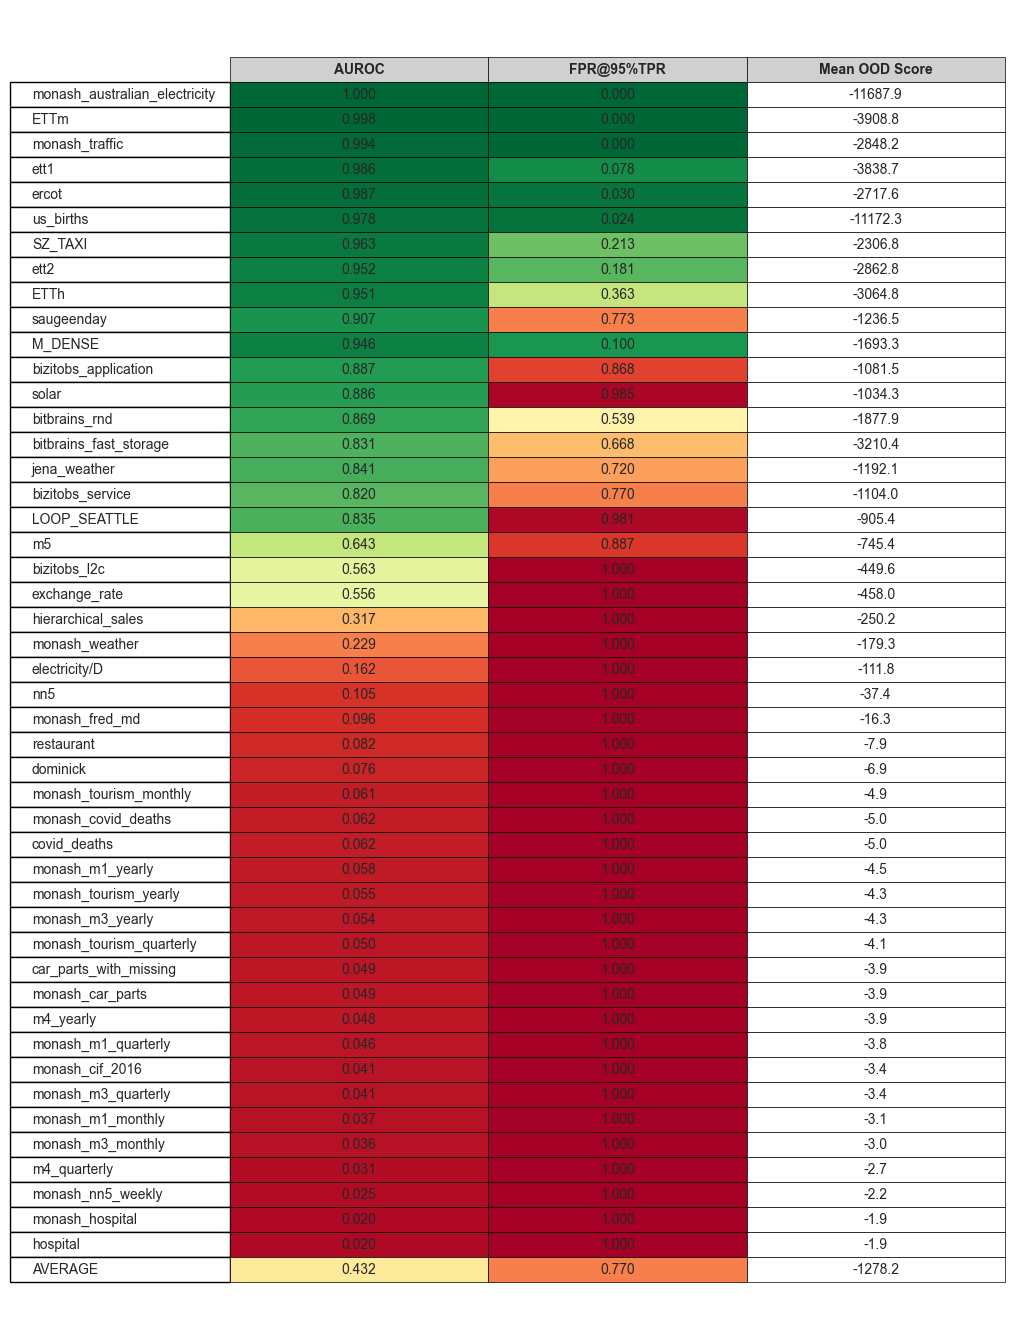

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def generate_individual_metric_tables(csv_path):
    if not os.path.exists(csv_path):
        print(f"Error: {csv_path} not found.")
        return

    # load data
    df = pd.read_csv(csv_path)
    modes = ['raw', 'only_l2', 'only_ln', 'l2_ln']
    metrics = ['AUROC', 'FPR@95TPR', 'mean_ood_score']
    
    pivoted = df.pivot(index='subset', columns='norm_mode')
    pivoted['global_avg_auroc'] = pivoted['AUROC'].mean(axis=1)
    pivoted = pivoted.sort_values('global_avg_auroc', ascending=False).drop(columns='global_avg_auroc')
    subsets = pivoted.index.tolist()

    cmap_auroc = plt.cm.RdYlGn  
    cmap_fpr = plt.cm.RdYlGn_r 

    for mode in modes:
        table_data = []
        mode_averages = pivoted.xs(mode, axis=1, level=1).mean()
        
        for subset in subsets:
            row = []
            for met in metrics:
                val = pivoted.loc[subset, (met, mode)]
                row.append(f"{val:.3f}" if met != 'mean_ood_score' else f"{val:.1f}")
            table_data.append(row)
        
        avg_row = []
        for met in metrics:
            val = mode_averages[met]
            avg_row.append(f"{val:.3f}" if met != 'mean_ood_score' else f"{val:.1f}")
        table_data.append(avg_row)

        plt.close('all') 
        
        # calculate height based on row count (approx 0.3 inches per row)
        num_rows = len(subsets) + 2
        dynamic_height = num_rows * 0.35 
        
        fig, ax = plt.subplots(figsize=(10, dynamic_height)) 
        ax.axis('off')
        
        col_labels = ["AUROC", "FPR@95%TPR", "Mean OOD Score"]
        
        table = ax.table(
            cellText=table_data, 
            rowLabels=subsets + ["AVERAGE"], 
            colLabels=col_labels, 
            loc='center', 
            cellLoc='center'
        )
        
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.0, 1.5)

        # coloring
        for r_idx in range(num_rows):
            for c_idx in range(3): 
                cell = table[r_idx, c_idx]
                if r_idx == 0: 
                    cell.set_facecolor('#d0d0d0')
                    cell.get_text().set_weight('bold')
                elif r_idx > 0:
                    val = mode_averages[metrics[c_idx]] if r_idx > len(subsets) else pivoted.iloc[r_idx-1][(metrics[c_idx], mode)]
                    if c_idx == 0: cell.set_facecolor(cmap_auroc(np.clip(val, 0, 1)))
                    elif c_idx == 1: cell.set_facecolor(cmap_fpr(np.clip(val, 0, 1)))
                    else: cell.set_facecolor("#ffffff")
                cell.set_linewidth(0.5)

        output_path = f"../outputs/metrics_{mode}.png"
        plt.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0.05)
        print(f"Generated: {output_path}")

if __name__ == "__main__":
    generate_individual_metric_tables("../outputs/metrics_summary.csv")

## Correlation between OOD Score and Prediction Error (MASE)


Dropped 14016 rows due to NaN or invalid MASE values.
Saved: ../outputs/correlation_mase_ood_raw.png


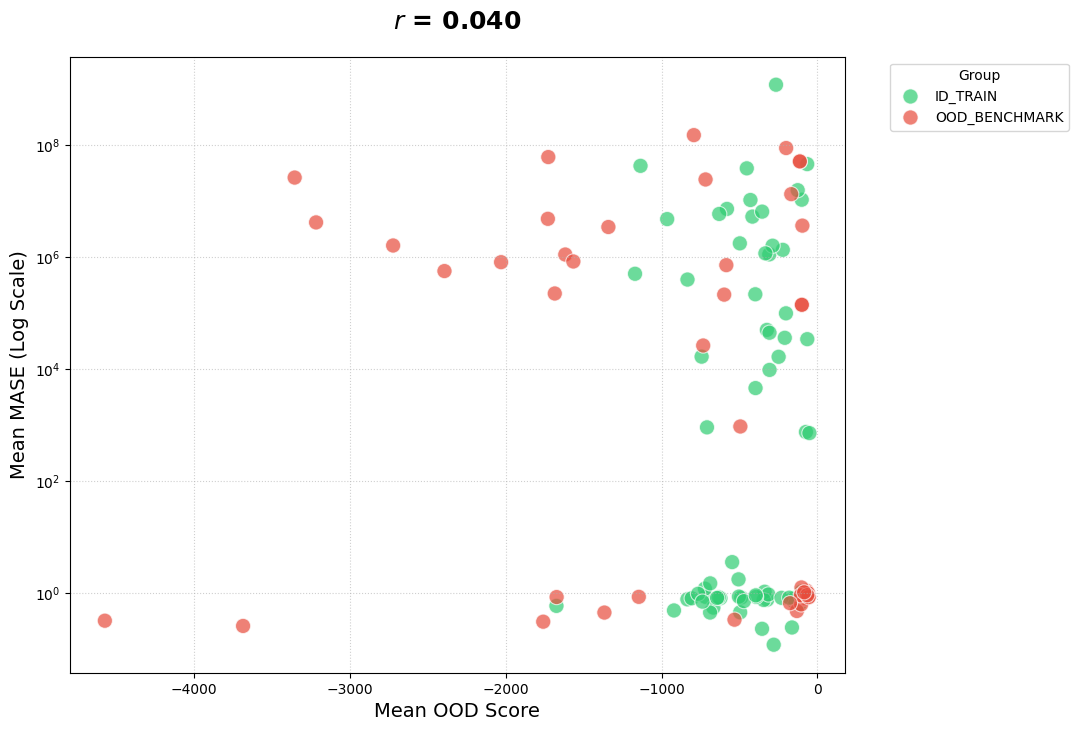

Saved: ../outputs/correlation_mase_ood_only_l2.png


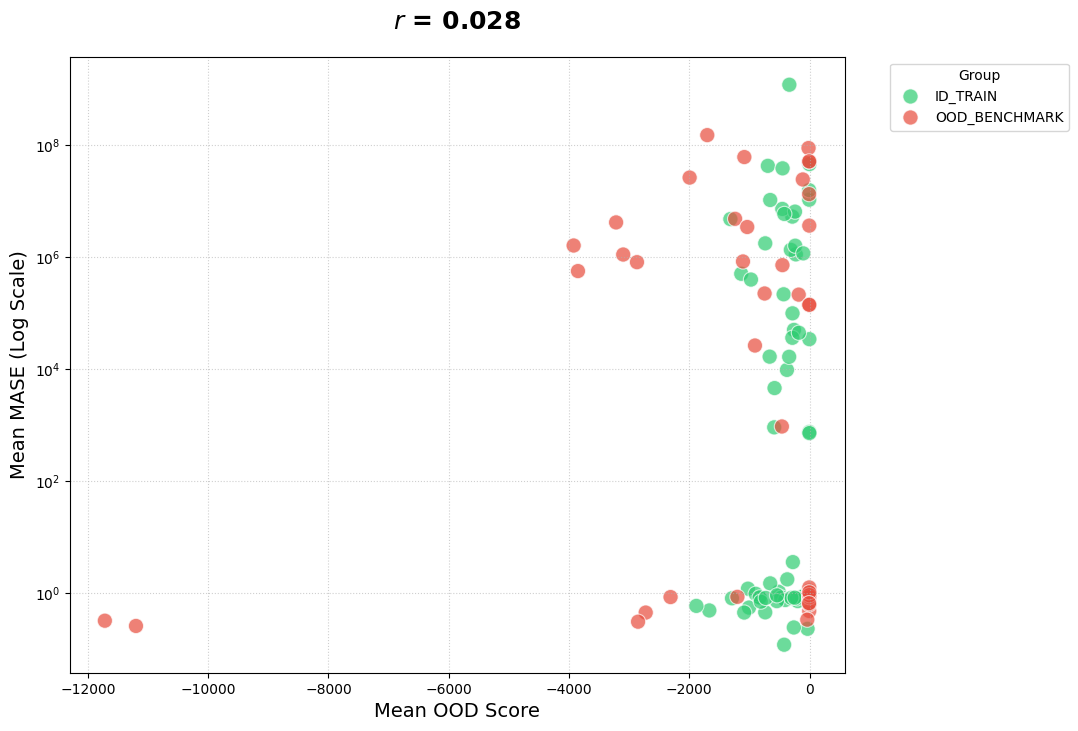

Saved: ../outputs/correlation_mase_ood_only_ln.png


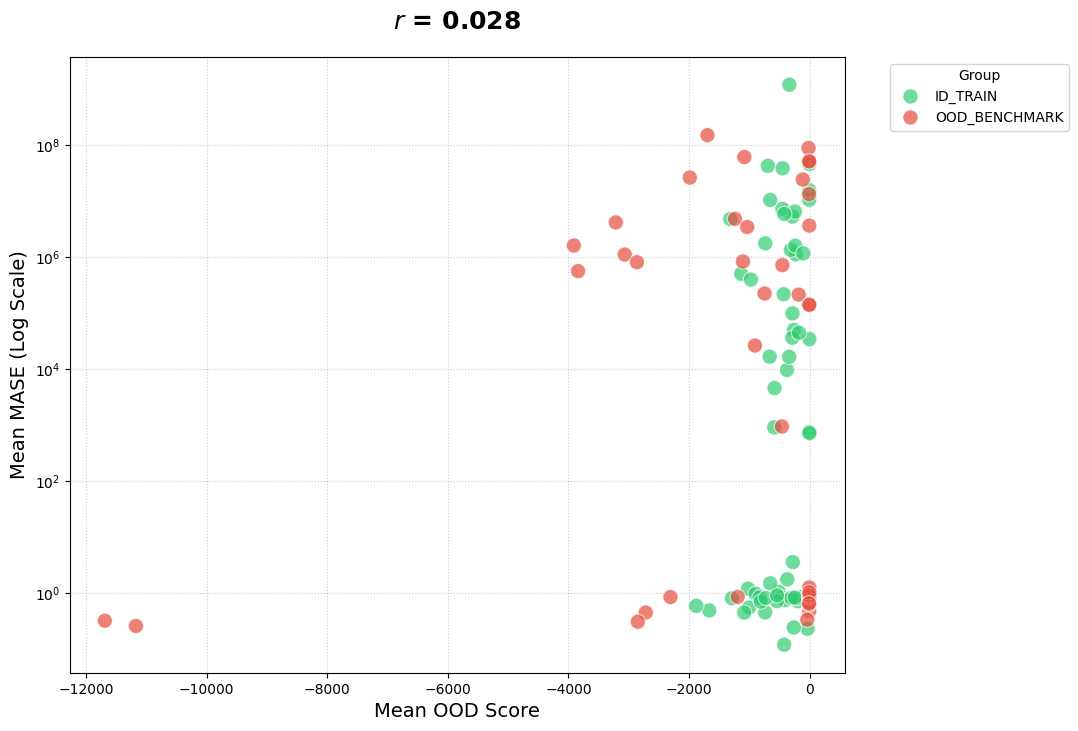

Saved: ../outputs/correlation_mase_ood_l2_ln.png


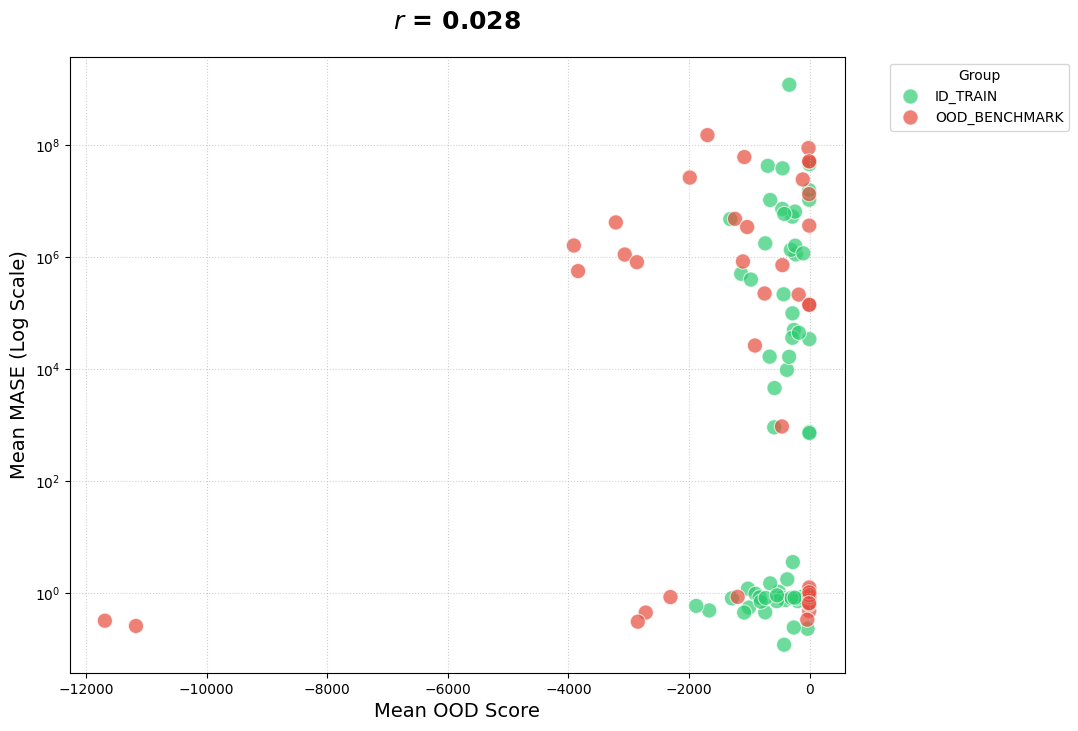

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr

def visualize_comprehensive_point_cloud(csv_path):
    if not os.path.exists(csv_path):
        print(f"Error: {csv_path} not found.")
        return

    df = pd.read_csv(csv_path)
    
    output_dir = "../outputs"

    # include ID training and OOD data
    allowed_groups = ['ID_TRAIN', 'OOD_BENCHMARK']
    df_plot = df[df['group'].isin(allowed_groups)].copy()
    
    # data cleaning
    initial_count = len(df_plot)
    df_plot = df_plot.dropna(subset=['mase', 'ood_score'])
    df_plot = df_plot[df_plot['mase'] > 0]
    
    dropped_count = initial_count - len(df_plot)
    if dropped_count > 0:
        print(f"Dropped {dropped_count} rows due to NaN or invalid MASE values.")

    # aggregate
    subset_means = df_plot.groupby(['group', 'norm_mode', 'subset'])[['mase', 'ood_score']].mean().reset_index()
    
    modes = ['raw', 'only_l2', 'only_ln', 'l2_ln']
    palette = {'ID_TRAIN': '#2ecc71', 'OOD_BENCHMARK': '#e74c3c'}
    
    # loop through each mode and create a separate figure
    for mode in modes:
        data = subset_means[subset_means['norm_mode'] == mode].copy()
        
        # create a new figure for each mode
        plt.figure(figsize=(10, 8))
        
        if data.empty or len(data) < 2:
            plt.title(f"Mode: {mode} (Insufficient Data)")
            plt.savefig(f"{output_dir}/correlation_{mode}.png")
            plt.close()
            continue
            
        # pearson correlation
        corr, _ = pearsonr(data['ood_score'], data['mase'])
        
        # create plot
        ax = sns.scatterplot(
            data=data,
            x='ood_score',
            y='mase',
            hue='group',
            palette=palette,
            s=120, 
            alpha=0.7,
            edgecolor='w',
            linewidth=0.8
        )
        
        # styling
        plt.title(f"$r$ = {corr:.3f}", fontsize=18, fontweight='bold', pad=20)
        plt.xlabel("Mean OOD Score", fontsize=14)
        plt.ylabel("Mean MASE", fontsize=14)
        plt.grid(True, linestyle=':', alpha=0.6)
        
        # log scaling check
        if data['mase'].max() / data['mase'].min() > 100:
            plt.yscale('log')
            plt.ylabel("Mean MASE (Log Scale)", fontsize=14)

        # legend adjustment
        plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')

        # save each figure individually
        output_filename = f"{output_dir}/correlation_mase_ood_{mode}.png"
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        print(f"Saved: {output_filename}")
        
        plt.show() 
        plt.close()

if __name__ == "__main__":
    visualize_comprehensive_point_cloud("../outputs/final_ood_scores.csv")

Dropped 11792 rows due to NaN or invalid MSE values.
Saved: ../outputs/correlation_mse_ood_raw.png


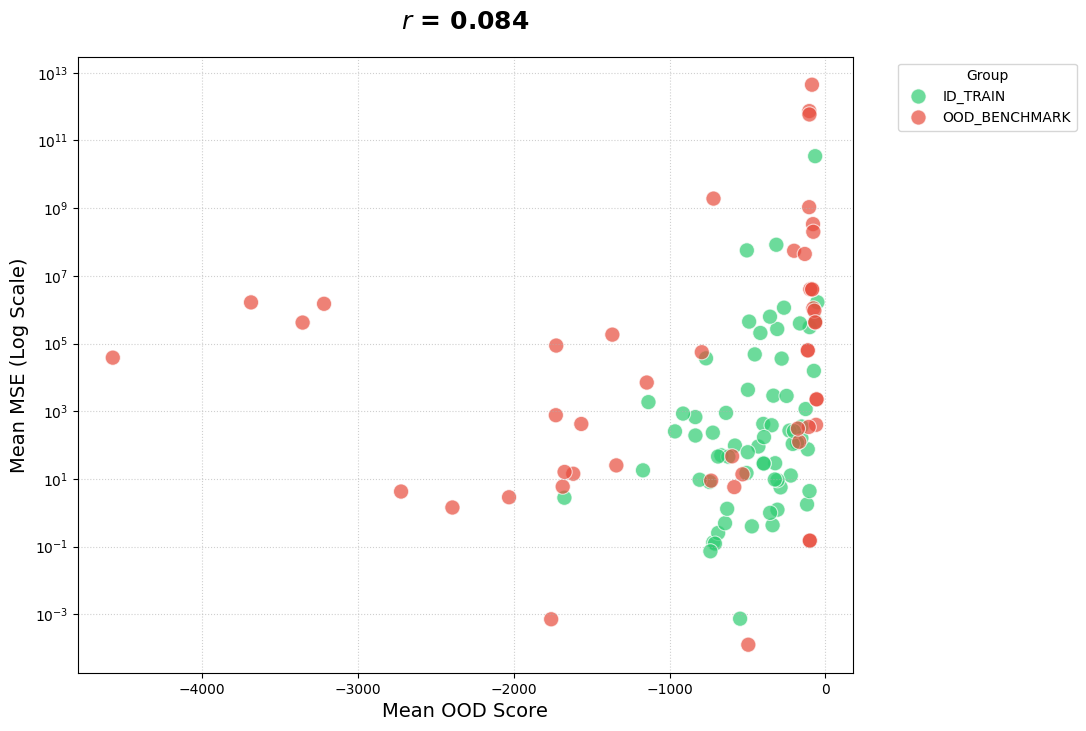

Saved: ../outputs/correlation_mse_ood_only_l2.png


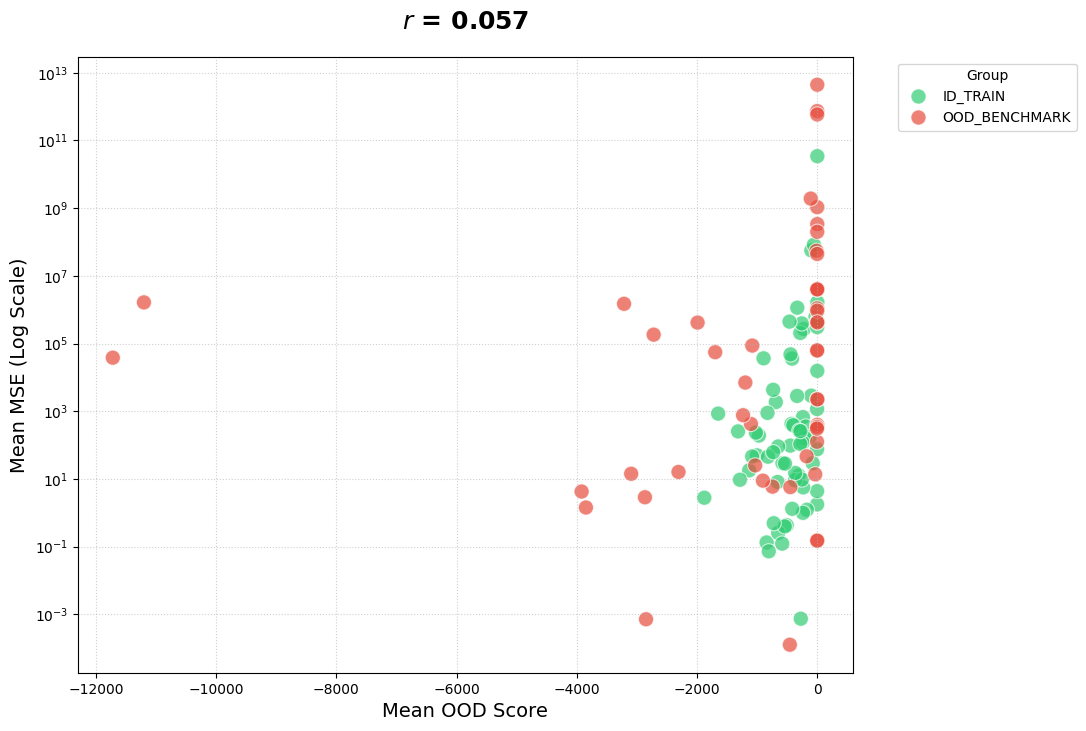

Saved: ../outputs/correlation_mse_ood_only_ln.png


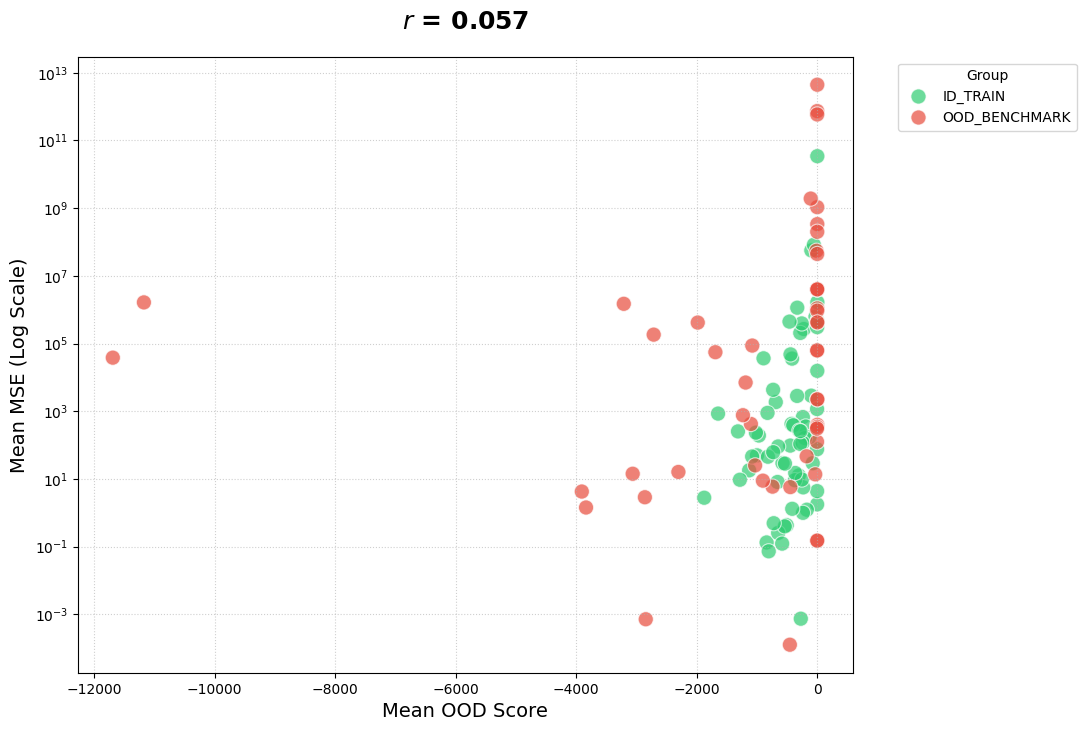

Saved: ../outputs/correlation_mse_ood_l2_ln.png


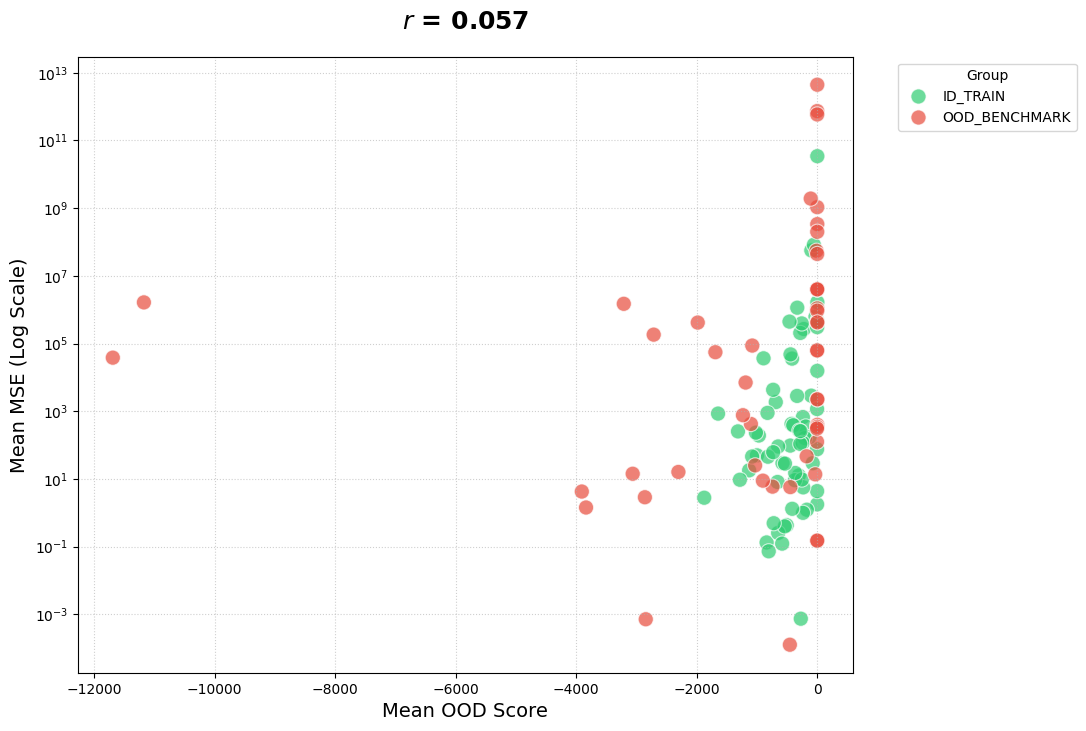

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr

def visualize_comprehensive_point_cloud(csv_path):
    if not os.path.exists(csv_path):
        print(f"Error: {csv_path} not found.")
        return

    df = pd.read_csv(csv_path)
    
    output_dir = "../outputs"

    # include ID training and OOD data
    allowed_groups = ['ID_TRAIN', 'OOD_BENCHMARK']
    df_plot = df[df['group'].isin(allowed_groups)].copy()
    
    # data cleaning
    initial_count = len(df_plot)
    df_plot = df_plot.dropna(subset=['mse', 'ood_score'])
    df_plot = df_plot[df_plot['mse'] > 0]
    
    dropped_count = initial_count - len(df_plot)
    if dropped_count > 0:
        print(f"Dropped {dropped_count} rows due to NaN or invalid MSE values.")

    # aggregate
    subset_means = df_plot.groupby(['group', 'norm_mode', 'subset'])[['mse', 'ood_score']].mean().reset_index()
    
    modes = ['raw', 'only_l2', 'only_ln', 'l2_ln']
    palette = {'ID_TRAIN': '#2ecc71', 'OOD_BENCHMARK': '#e74c3c'}
    
    # loop through each mode and create a separate figure
    for mode in modes:
        data = subset_means[subset_means['norm_mode'] == mode].copy()
        
        # create a new figure for each mode
        plt.figure(figsize=(10, 8))
        
        if data.empty or len(data) < 2:
            plt.title(f"Mode: {mode} (Insufficient Data)")
            plt.savefig(f"{output_dir}/correlation_{mode}.png")
            plt.close()
            continue
            
        # pearson correlation
        corr, _ = pearsonr(data['ood_score'], data['mse'])
        
        # create plot
        ax = sns.scatterplot(
            data=data,
            x='ood_score',
            y='mse',
            hue='group',
            palette=palette,
            s=120, 
            alpha=0.7,
            edgecolor='w',
            linewidth=0.8
        )
        
        # styling
        plt.title(f"$r$ = {corr:.3f}", fontsize=18, fontweight='bold', pad=20)
        plt.xlabel("Mean OOD Score", fontsize=14)
        plt.ylabel("Mean MSE", fontsize=14)
        plt.grid(True, linestyle=':', alpha=0.6)
        
        # log scaling check
        if data['mse'].max() / data['mse'].min() > 100:
            plt.yscale('log')
            plt.ylabel("Mean MSE (Log Scale)", fontsize=14)

        # legend adjustment
        plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')

        # save each figure individually
        output_filename = f"{output_dir}/correlation_mse_ood_{mode}.png"
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        print(f"Saved: {output_filename}")
        
        plt.show() 
        plt.close()

if __name__ == "__main__":
    visualize_comprehensive_point_cloud("../outputs/final_ood_scores.csv")